# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

## Business Understanding

### Latar Belakang
Jaya Jaya Institut merupakan salah satu institusi pendidikan perguruan yang telah berdiri sejak tahun 2000 dan telah mencetak banyak lulusan dengan reputasi yang sangat baik. Namun, institusi ini menghadapi masalah signifikan yaitu masih banyak siswa yang tidak menyelesaikan pendidikannya (dropout).

Tingginya angka dropout menjadi masalah besar yang dapat mempengaruhi:
- Reputasi institusi
- Efisiensi biaya operasional
- Peluang karier graduates
- Rate of return investasi pendidikan

### Permasalahan Bisnis
1. **Tingginya angka dropout** - Proporsi siswa yang tidak menyelesaikan pendidikan cukup tinggi (~32%)
2. **Kurangnya deteksi dini** - Institusi belum memiliki sistem prediktif untuk mengidentifikasi siswa berisiko
3. **Tidak efektifnya intervensi** - Akibat tidak ada deteksi dini, bimbingan khusus tidak dapat diberikan secara tepat waktu

### Cakupan Proyek
Proyek ini mencakup pengembangan:
1. **Analisis Data** - Eksplorasi data untuk memahami karakteristik mahasiswa
2. **Machine Learning** - Model prediktif untuk mendeteksi risiko dropout
3. **Dashboard** - Visualisasi data untuk monitoring performa siswa
4. **Prototype** - Sistem prediksi interaktif berbasis Streamlit

- Nama: Fahru Alfarizi Hananza Putrawan
- Email: fahrualfarizi7@gmail.com
- Id Dicoding: fahrual_19

## Persiapan

### Menyiapkan library yang dibutuhkan

In [14]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# Menampilkan versi library
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: sklearn imported")

Pandas version: 3.0.3
NumPy version: 2.4.6
Scikit-learn version: sklearn imported


### Menyiapkan data yang akan digunakan

In [15]:
# Memuat dataset
df = pd.read_csv('data.csv', sep=';')

# Menampilkan dimensi dataset
print(f"Dimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
print("\n")

# Menampilkan 5 data pertama
df.head()

Dimensi dataset: 4424 baris, 37 kolom




,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Pada tahap ini, kita akan melakukan eksplorasi data untuk memahami karakteristik dataset lebih dalam.

In [16]:
# Informasi dataset
print("Informasi Dataset:")
print("="*50)
df.info()
print("\n")

# Statistik deskriptif
print("\nStatistik Deskriptif:")
print("="*50)
df.describe()

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000



Distribusi Target Variable (Status):
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


Persentase:
Status
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


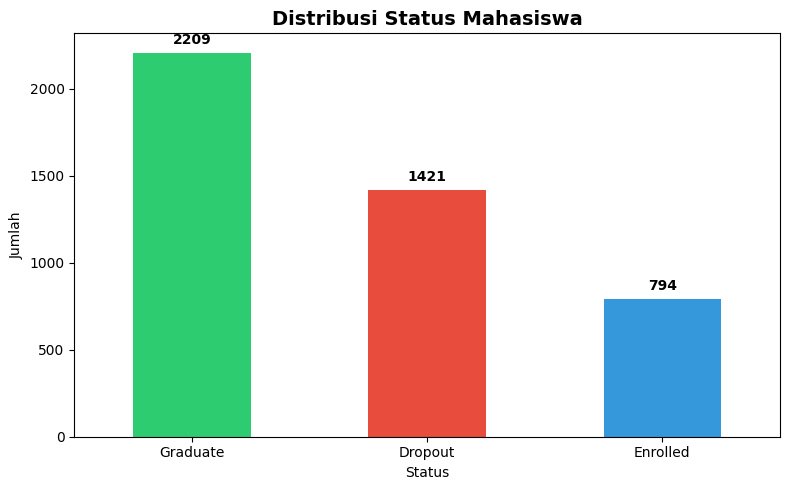

In [17]:
# Analisis distribusi target variable (Status)
print("\nDistribusi Target Variable (Status):")
print("="*50)
print(df['Status'].value_counts())
print("\n")
print("Persentase:")
print(df['Status'].value_counts(normalize=True) * 100)

# Visualisasi distribusi Status
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c', '#3498db']
df['Status'].value_counts().plot(kind='bar', color=colors)
plt.title('Distribusi Status Mahasiswa', fontsize=14, fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
for i, v in enumerate(df['Status'].value_counts()):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Pengecekan missing values
print("\nMissing Values:")
print("="*50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing Percentage': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []

Total missing values: 0


### Analisis Korelasi dengan Status

Mari kita lihat korelasi antara fitur-fitur numerik dengan target variable.

Encoding Status:  {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

Korelasi dengan Status (encoded):
Status_encoded                                  1.000000
Curricular_units_2nd_sem_approved               0.624157
Curricular_units_2nd_sem_grade                  0.566827
Curricular_units_1st_sem_approved               0.529123
Curricular_units_1st_sem_grade                  0.485207
Tuition_fees_up_to_date                         0.409827
Scholarship_holder                              0.297595
Curricular_units_2nd_sem_enrolled               0.175847
Curricular_units_1st_sem_enrolled               0.155974
Admission_grade                                 0.120889
Displaced                                       0.113986
Previous_qualification_grade                    0.103764
Curricular_units_2nd_sem_evaluations            0.092721
Application_order                               0.089791
Daytime_evening_attendance                      0.075107
Curricular_units_

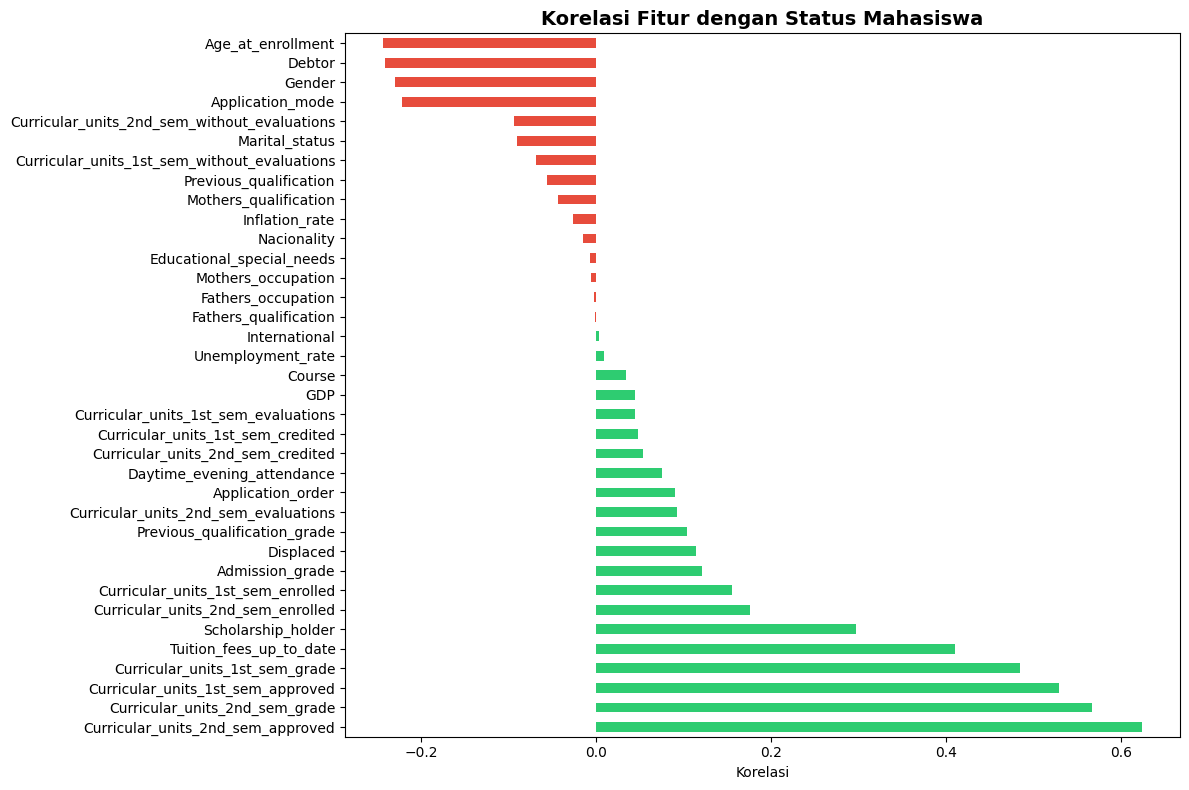

In [19]:
# Encode target variable untuk analisis korelasi
le = LabelEncoder()
df['Status_encoded'] = le.fit_transform(df['Status'])
print("Encoding Status: ", dict(zip(le.classes_, le.transform(le.classes_))))

# Korelasi fitur dengan target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlations = df[numeric_cols].corr()['Status_encoded'].sort_values(ascending=False)
print("\nKorelasi dengan Status (encoded):")
print(correlations)

# Visualisasi korelasi fitur penting
plt.figure(figsize=(12, 8))
corr_with_target = correlations.drop('Status_encoded')
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in corr_with_target.values]
corr_with_target.plot(kind='barh', color=colors)
plt.title('Korelasi Fitur dengan Status Mahasiswa', fontsize=14, fontweight='bold')
plt.xlabel('Korelasi')
plt.tight_layout()
plt.show()

## Data Preparation / Preprocessing

Pada tahap ini, kita akan melakukan pembersihan dan persiapan data sebelum modeling.

In [20]:
# Mengubah target menjadi binary: Dropout (1) vs Non-Dropout (0)
# Graduate dan Enrolled dianggap sebagai "Belum Dropout"
df['Target'] = (df['Status'] == 'Dropout').astype(int)
print("Distribusi Target (Binary):")
print(df['Target'].value_counts())
print(f"\nProporsi Dropout: {df['Target'].mean()*100:.2f}%")

# Menghapus kolom Status dan Status_encoded (sudah di-encode ke Target)
df_model = df.drop(['Status', 'Status_encoded'], axis=1)
print(f"\nDataset siap untuk modeling: {df_model.shape}")

Distribusi Target (Binary):
Target
0    3003
1    1421
Name: count, dtype: int64

Proporsi Dropout: 32.12%

Dataset siap untuk modeling: (4424, 37)


In [21]:
# Memisahkan fitur dan target
X = df_model.drop('Target', axis=1)
y = df_model['Target']

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Training: {X_train.shape[0]} sampel")
print(f"Data Testing: {X_test.shape[0]} sampel")
print(f"\nDistribusi target training:")
print(y_train.value_counts())
print(f"\nDistribusi target testing:")
print(y_test.value_counts())

Data Training: 3539 sampel
Data Testing: 885 sampel

Distribusi target training:
Target
0    2402
1    1137
Name: count, dtype: int64

Distribusi target testing:
Target
0    601
1    284
Name: count, dtype: int64


In [22]:
# Feature Scaling menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling dilakukan!")
print(f"Shape X_train_scaled: {X_train_scaled.shape}")
print(f"Shape X_test_scaled: {X_test_scaled.shape}")

Feature Scaling dilakukan!
Shape X_train_scaled: (3539, 36)
Shape X_test_scaled: (885, 36)


## Modeling

Pada tahap ini, kita akan membangun model Machine Learning untuk memprediksi kemungkinan dropout mahasiswa.

In [23]:
# Membangun model Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Training model
print("Melatih model Random Forest...")
rf_model.fit(X_train_scaled, y_train)
print("Model berhasil dilatih!")

# Prediksi pada data testing
y_pred = rf_model.predict(X_test_scaled)

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Fitur Paling Penting:")
print(feature_importance.head(10))

Melatih model Random Forest...
Model berhasil dilatih!

Top 10 Fitur Paling Penting:
                                 feature  importance
30     Curricular_units_2nd_sem_approved    0.173997
31        Curricular_units_2nd_sem_grade    0.146506
24     Curricular_units_1st_sem_approved    0.105525
16               Tuition_fees_up_to_date    0.074856
25        Curricular_units_1st_sem_grade    0.065675
19                     Age_at_enrollment    0.044367
29  Curricular_units_2nd_sem_evaluations    0.032330
23  Curricular_units_1st_sem_evaluations    0.028442
12                       Admission_grade    0.027787
3                                 Course    0.027627


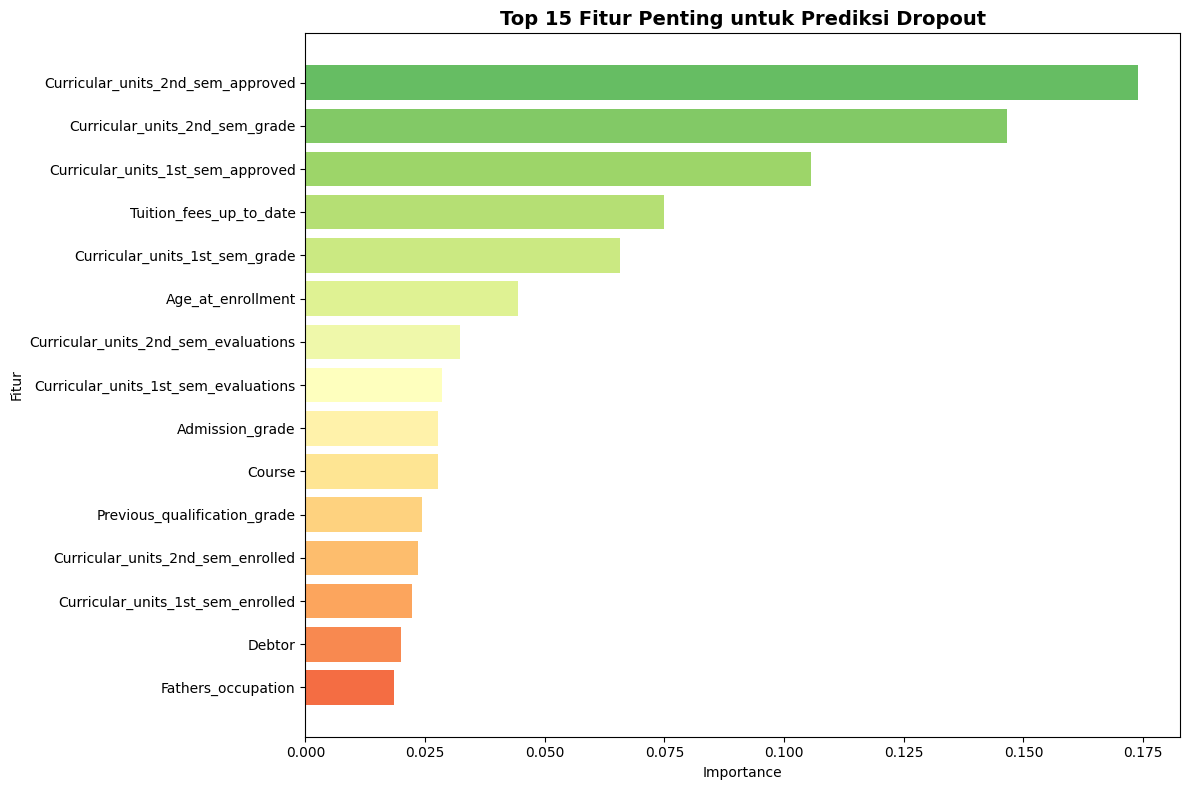


Insight:
- Fitur 'Curricular_units_approved' (satuan kurikulum yang disetujui) adalah
  fitur paling penting dalam memprediksi dropout.
- Fitur lain yang juga penting: nilai, usia, dan status pembayaran tuition.


In [24]:
# Visualisasi Feature Importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top_features)))[::-1]
plt.barh(range(len(top_features)), top_features['importance'].values, color=colors)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance')
plt.ylabel('Fitur')
plt.title('Top 15 Fitur Penting untuk Prediksi Dropout', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nInsight:")
print("- Fitur 'Curricular_units_approved' (satuan kurikulum yang disetujui) adalah")
print("  fitur paling penting dalam memprediksi dropout.")
print("- Fitur lain yang juga penting: nilai, usia, dan status pembayaran tuition.")

## Evaluation

Pada tahap ini, kita akan mengevaluasi performa model yang telah dibangun.

EVALUASI MODEL RANDOM FOREST

Accuracy: 87.91%

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.88      0.95      0.91       601
     Dropout       0.88      0.72      0.79       284

    accuracy                           0.88       885
   macro avg       0.88      0.84      0.85       885
weighted avg       0.88      0.88      0.88       885

F1 Score: 79.30%


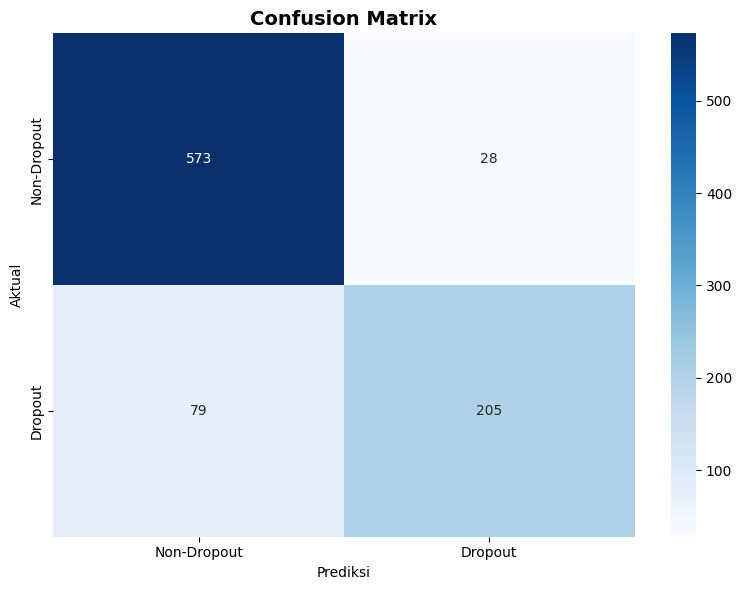


Interpretasi:
- True Negatives (Non-Dropout benar): 573
- False Positives (Salah prediksi Dropout): 28
- False Negatives (Salah prediksi Non-Dropout): 79
- True Positives (Dropout benar): 205


In [25]:
# Evaluasi Model
print("="*60)
print("EVALUASI MODEL RANDOM FOREST")
print("="*60)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy*100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Dropout', 'Dropout']))

# F1 Score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1*100:.2f}%")

# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Dropout', 'Dropout'],
            yticklabels=['Non-Dropout', 'Dropout'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

print("\nInterpretasi:")
print(f"- True Negatives (Non-Dropout benar): {cm[0][0]}")
print(f"- False Positives (Salah prediksi Dropout): {cm[0][1]}")
print(f"- False Negatives (Salah prediksi Non-Dropout): {cm[1][0]}")
print(f"- True Positives (Dropout benar): {cm[1][1]}")

In [26]:
# Menyimpan model dan scaler untuk deployment
import joblib
import os

# Membuat folder model jika belum ada
os.makedirs('model', exist_ok=True)

# Simpan model
joblib.dump(rf_model, 'model/rf_model.joblib')
print("Model berhasil disimpan di 'model/rf_model.joblib'")

# Simpan scaler
joblib.dump(scaler, 'model/scaler.joblib')
print("Scaler berhasil disimpan di 'model/scaler.joblib'")

# Simpan feature names
joblib.dump(list(X.columns), 'model/feature_names.joblib')
print("Feature names berhasil disimpan di 'model/feature_names.joblib'")

# Simpan label encoder
joblib.dump(le, 'model/label_encoder.joblib')
print("Label encoder berhasil disimpan di 'model/label_encoder.joblib'")

print("\nSemua artefak model siap untuk deployment!")

Model berhasil disimpan di 'model/rf_model.joblib'
Scaler berhasil disimpan di 'model/scaler.joblib'
Feature names berhasil disimpan di 'model/feature_names.joblib'
Label encoder berhasil disimpan di 'model/label_encoder.joblib'

Semua artefak model siap untuk deployment!
